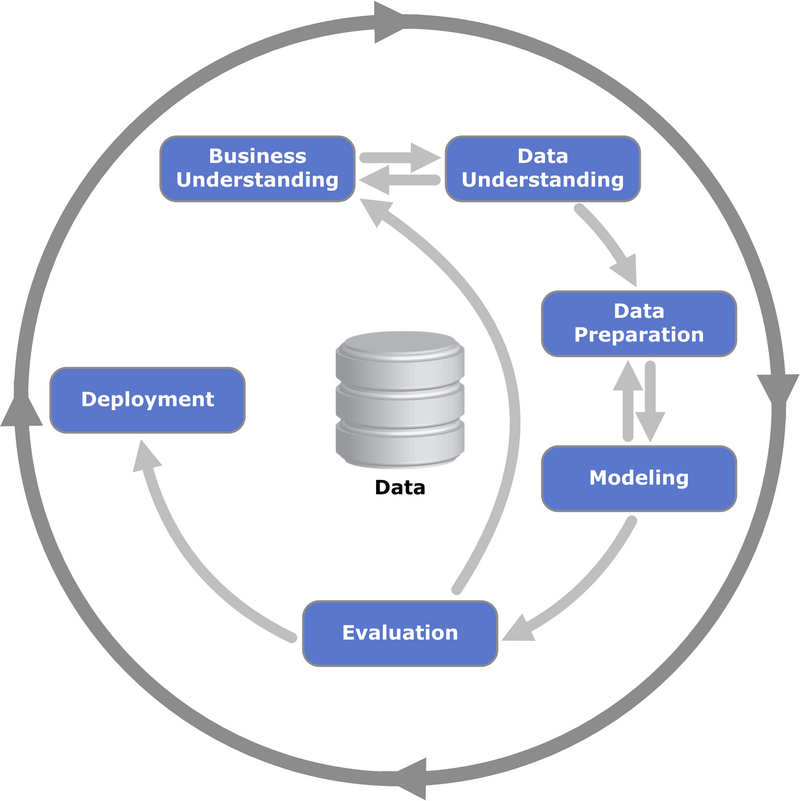

## ETAPAS DO CRISP-DM

1. Business Understanding: Entende o problema de negócio e se é possivel resolver com IA

2. Data Understanding: Importa dados. Entende os dados (EDA) e encontra possíveis problemas nos dados

3. Data Preparation: Trata dados, Seleciona dados (Feature Engineering) e Preprocessamento de Dados (Enconding e Scale)

### BUSINESS UNDERSTANDING

Criar um modelo de IA que baseado em caracteristicas e infos do filme, prever a receita

### DATA UNDERSTANDING - EDA

In [ ]:
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import LogisticRegression

In [ ]:
df = pd.read_csv("imdb_top_1000.csv")

In [ ]:
df.drop(columns="Poster_Link", inplace=True)

In [ ]:
df.head()

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142 min,Drama,9.30,Two imprisoned men bond over a number of years...,80.00,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,The Godfather,1972,A,175 min,"Crime, Drama",9.20,An organized crime dynasty's aging patriarch t...,100.00,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.00,When the menace known as the Joker wreaks havo...,84.00,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.00,The early life and career of Vito Corleone in ...,90.00,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.00,A jury holdout attempts to prevent a miscarria...,96.00,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [ ]:
df.dtypes

,0
Series_Title,object
Released_Year,object
Certificate,object
Runtime,object
Genre,object
IMDB_Rating,float64
Overview,object
Meta_score,float64
Director,object
Star1,object


In [ ]:
df['Gross'][0]

'28,341,469'

In [ ]:
df['Gross'] = df['Gross'].str.replace(",", "")

In [ ]:
df['Gross'] = df['Gross'].astype('float')

In [ ]:
df.dtypes

,0
Series_Title,object
Released_Year,object
Certificate,object
Runtime,object
Genre,object
IMDB_Rating,float64
Overview,object
Meta_score,float64
Director,object
Star1,object


In [ ]:
df["Released_Year"].unique()

array(['1994', '1972', '2008', '1974', '1957', '2003', '1993', '2010',
       '1999', '2001', '1966', '2002', '1990', '1980', '1975', '2020',
       '2019', '2014', '1998', '1997', '1995', '1991', '1977', '1962',
       '1954', '1946', '2011', '2006', '2000', '1988', '1985', '1968',
       '1960', '1942', '1936', '1931', '2018', '2017', '2016', '2012',
       '2009', '2007', '1984', '1981', '1979', '1971', '1963', '1964',
       '1950', '1940', '2013', '2005', '2004', '1992', '1987', '1986',
       '1983', '1976', '1973', '1965', '1959', '1958', '1952', '1948',
       '1944', '1941', '1927', '1921', '2015', '1996', '1989', '1978',
       '1961', '1955', '1953', '1925', '1924', '1982', '1967', '1951',
       '1949', '1939', '1937', '1934', '1928', '1926', '1920', '1970',
       '1969', '1956', '1947', '1945', '1930', '1938', '1935', '1933',
       '1932', '1922', '1943', 'PG'], dtype=object)

In [ ]:
df['Released_Year'][966] = "1995"

/tmp/ipython-input-2134638031.py:1: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/tmp/ipython-input-2134638031.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documen

In [ ]:
df["Released_Year"] = df["Released_Year"].astype('int')

In [ ]:
df['Runtime'].unique()

array(['142 min', '175 min', '152 min', '202 min', '96 min', '201 min',
       '154 min', '195 min', '148 min', '139 min', '178 min', '161 min',
       '179 min', '136 min', '146 min', '124 min', '133 min', '160 min',
       '132 min', '153 min', '169 min', '130 min', '125 min', '189 min',
       '116 min', '127 min', '118 min', '121 min', '207 min', '122 min',
       '106 min', '112 min', '151 min', '150 min', '155 min', '119 min',
       '110 min', '88 min', '137 min', '89 min', '165 min', '109 min',
       '102 min', '87 min', '126 min', '147 min', '117 min', '181 min',
       '149 min', '105 min', '164 min', '170 min', '98 min', '101 min',
       '113 min', '134 min', '229 min', '115 min', '143 min', '95 min',
       '104 min', '123 min', '131 min', '108 min', '81 min', '99 min',
       '114 min', '129 min', '228 min', '128 min', '103 min', '107 min',
       '68 min', '138 min', '156 min', '167 min', '163 min', '186 min',
       '321 min', '135 min', '140 min', '180 min', '158 min'

In [ ]:
df['Runtime'] = df['Runtime'].str.replace(" min", "")

In [ ]:
df['Runtime'] = df['Runtime'].astype(int)

In [ ]:
pd.options.display.float_format = '{:.2f}'.format

In [ ]:
df.describe()

,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Gross
count,1000.00,1000.00,1000.00,843.00,1000.00,831.00
mean,1991.22,122.89,7.95,77.97,273692.91,68034750.87
std,23.29,28.09,0.28,12.38,327372.70,109750043.19
min,1920.00,45.00,7.60,28.00,25088.00,1305.00
25%,1976.00,103.00,7.70,70.00,55526.25,3253559.00
50%,1999.00,119.00,7.90,79.00,138548.50,23530892.00
75%,2009.00,137.00,8.10,87.00,374161.25,80750893.50
max,2020.00,321.00,9.30,100.00,2343110.00,936662225.00


In [ ]:
df.dropna(subset=['Gross'], inplace=True)

In [ ]:
df.describe(include="object")

,Series_Title,Certificate,Genre,Overview,Director,Star1,Star2,Star3,Star4
count,831,785,831,831,831,831,831,831,831
unique,831,13,182,831,472,556,704,737,782
top,From Here to Eternity,U,Drama,"In Hawaii in 1941, a private is cruelly punish...",Steven Spielberg,Tom Hanks,Emma Watson,Rupert Grint,Michael Caine
freq,1,200,75,1,13,12,7,5,4


In [ ]:
fig = px.histogram(df, x="Gross")
fig.show()

In [ ]:
fig = px.line(df, x="Gross", y="IMDB_Rating", title='Filmes com melhor Nota ganham mais dinheiro?')
fig.show()

### DATA PREPARATION

In [ ]:
df.head()

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142,Drama,9.30,Two imprisoned men bond over a number of years...,80.00,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.00
1,The Godfather,1972,A,175,"Crime, Drama",9.20,An organized crime dynasty's aging patriarch t...,100.00,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.00
2,The Dark Knight,2008,UA,152,"Action, Crime, Drama",9.00,When the menace known as the Joker wreaks havo...,84.00,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.00
3,The Godfather: Part II,1974,A,202,"Crime, Drama",9.00,The early life and career of Vito Corleone in ...,90.00,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.00
4,12 Angry Men,1957,U,96,"Crime, Drama",9.00,A jury holdout attempts to prevent a miscarria...,96.00,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.00


In [ ]:
df['Director'].unique()

array(['Frank Darabont', 'Francis Ford Coppola', 'Christopher Nolan',
       'Sidney Lumet', 'Peter Jackson', 'Quentin Tarantino',
       'Steven Spielberg', 'David Fincher', 'Robert Zemeckis',
       'Sergio Leone', 'Lana Wachowski', 'Martin Scorsese',
       'Irvin Kershner', 'Milos Forman', 'Bong Joon Ho',
       'Fernando Meirelles', 'Hayao Miyazaki', 'Roberto Benigni',
       'Jonathan Demme', 'George Lucas', 'Akira Kurosawa',
       'Todd Phillips', 'Damien Chazelle', 'Olivier Nakache',
       'Roman Polanski', 'Ridley Scott', 'Tony Kaye', 'Bryan Singer',
       'Luc Besson', 'Roger Allers', 'James Cameron',
       'Giuseppe Tornatore', 'Alfred Hitchcock', 'Michael Curtiz',
       'Charles Chaplin', 'Nadine Labaki', 'Makoto Shinkai',
       'Nitesh Tiwari', 'Bob Persichetti', 'Anthony Russo', 'Lee Unkrich',
       'Rajkumar Hirani', 'Aamir Khan', 'Andrew Stanton',
       'Florian Henckel von Donnersmarck', 'Chan-wook Park',
       'Stanley Kubrick', 'Billy Wilder', 'Sam Mendes', 

In [ ]:
len(df['Director'].unique())

472

### PREPROCESSAMENTO DE DADOS

In [ ]:
df = pd.get_dummies(df, columns=['Director'], prefix='Director', dummy_na=False)

In [ ]:
df['Director_Woody Allen'][0]

np.False_

In [ ]:
df.columns

Index(['Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre',
       'IMDB_Rating', 'Overview', 'Meta_score', 'Star1', 'Star2',
       ...
       'Director_Woody Allen', 'Director_Xavier Dolan',
       'Director_Yann Samuell', 'Director_Yash Chopra', 'Director_Yimou Zhang',
       'Director_Yoshiaki Kawajiri', 'Director_Yôjirô Takita',
       'Director_Zack Snyder', 'Director_Zaza Urushadze',
       'Director_Zoya Akhtar'],
      dtype='object', length=486)

In [ ]:
df.drop(columns=['Series_Title', 'Certificate', 'Overview', 'Star1', 'Star2', 'Star3', 'Star4'], inplace=True)

In [ ]:
df.head()

,Released_Year,Runtime,Genre,IMDB_Rating,Meta_score,No_of_Votes,Gross,Director_Aamir Khan,Director_Abdellatif Kechiche,Director_Abhishek Kapoor,...,Director_Woody Allen,Director_Xavier Dolan,Director_Yann Samuell,Director_Yash Chopra,Director_Yimou Zhang,Director_Yoshiaki Kawajiri,Director_Yôjirô Takita,Director_Zack Snyder,Director_Zaza Urushadze,Director_Zoya Akhtar
0,1994,142,Drama,9.30,80.00,2343110,28341469.00,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1972,175,"Crime, Drama",9.20,100.00,1620367,134966411.00,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2008,152,"Action, Crime, Drama",9.00,84.00,2303232,534858444.00,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1974,202,"Crime, Drama",9.00,90.00,1129952,57300000.00,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1957,96,"Crime, Drama",9.00,96.00,689845,4360000.00,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X = df.drop(columns="Gross")
y = df['Gross']

# EXECUTE O StandartScaler nas variáveis Numéricas

In [ ]:
X_numeric = X.select_dtypes(include='number')
X_categorical = X.select_dtypes(exclude='number')

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(X_numeric)

StandardScaler()

In [ ]:
X_scaled = scaler.transform(X_numeric)

In [ ]:
X_scaled = pd.DataFrame(X_scaled, columns=X_numeric.columns)

In [ ]:
display(X_scaled.head())

,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes
0,0.00,0.65,4.78,0.20,5.90
1,-1.04,1.85,4.43,1.81,3.80
2,0.67,1.02,3.72,0.52,5.79
3,-0.94,2.84,3.72,1.00,2.37
4,-1.75,-1.02,3.72,1.48,1.09


In [ ]:
X_processed = pd.concat([X_scaled, X_categorical], axis=1)
display(X_processed.head())

,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes,Genre,Director_Aamir Khan,Director_Abdellatif Kechiche,Director_Abhishek Kapoor,Director_Adam McKay,...,Director_Woody Allen,Director_Xavier Dolan,Director_Yann Samuell,Director_Yash Chopra,Director_Yimou Zhang,Director_Yoshiaki Kawajiri,Director_Yôjirô Takita,Director_Zack Snyder,Director_Zaza Urushadze,Director_Zoya Akhtar
0,0.00,0.65,4.78,0.20,5.90,Drama,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,-1.04,1.85,4.43,1.81,3.80,"Crime, Drama",False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.67,1.02,3.72,0.52,5.79,"Action, Crime, Drama",False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-0.94,2.84,3.72,1.00,2.37,"Crime, Drama",False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-1.75,-1.02,3.72,1.48,1.09,"Crime, Drama",False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
X_processed.dropna(inplace=True)

In [ ]:
X_scaled

,Released_Year,Runtime,IMDB_Rating,Meta_score,No_of_Votes
0,0.00,0.65,4.78,0.20,5.90
1,-1.04,1.85,4.43,1.81,3.80
2,0.67,1.02,3.72,0.52,5.79
3,-0.94,2.84,3.72,1.00,2.37
4,-1.75,-1.02,3.72,1.48,1.09
...,...,...,...,...,...
826,-1.09,1.20,-1.23,-0.04,-0.83
827,-1.13,0.72,-1.23,-2.20,-0.79
828,-1.27,-1.68,-1.23,-1.00,-0.43
829,-1.42,-1.35,-1.23,1.48,-0.80


# MODELING

In [ ]:
print(X_scaled.isna().sum())

X_scaled = X_scaled.dropna()
y = y[X_scaled.index]

Released_Year     0
Runtime           0
IMDB_Rating       0
Meta_score       81
No_of_Votes       0
dtype: int64


KeyError: '[18, 20, 30, 32, 46, 54, 55, 76, 77, 80, 82, 85, 87, 91, 92, 130, 140, 160, 163, 166, 175, 176, 177, 180, 181, 182, 188, 192, 197, 198, 205, 211, 224, 228, 229, 238, 246, 258, 273, 276, 280, 281, 289, 292, 294, 295, 296, 298, 299, 301, 303, 306, 308, 318, 322, 323, 324, 326, 351, 353, 366, 379, 381, 409, 412, 425, 428, 433, 440, 441, 443, 444, 445, 446, 449, 450, 451, 455, 464, 495, 500, 504, 518, 522, 538, 540, 541, 548, 550, 553, 554, 557, 562, 567, 568, 569, 570, 571, 574, 577, 587, 601, 608, 612, 613, 641, 672, 690, 692, 702, 706, 709, 710, 711, 713, 714, 715, 717, 718, 720, 761, 762, 798, 814, 822, 829] not in index'

In [ ]:
# MODELO 1: Logistic Regression - LEMBRAR DE IMPORTAR A LIB: from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(random_state=0).fit(X_scaled, y)

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
clf.score(X_scaled, y)

In [ ]:
# MODELO 2: Support Vector Regression - LEMBRAR DE IMPORTAR A LIB: from sklearn.svm import SVR
svr = SVR(C=1.0, epsilon=0.2)

In [ ]:
svr.fit(X_scaled, y)

In [ ]:
svr.score(X_scaled, y)